In [1]:
""" This demo takes OLMoE as an example. """
import sys
sys.path.append(".")
import os
import torch
from tools import *
from dataset.c4_dataset import *
from dataset.ioi_dataset import *
from transformers import AutoTokenizer
from huggingface_hub import list_repo_refs
out = list_repo_refs("allenai/OLMoE-1B-7B-0924")
branches = [b.name for b in out.branches]
print(branches)
###-------- Basic settings --------####
# output_dir = "./results/"
output_dir = "./results/step10000-tokens41B"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
torch.set_default_device("cuda:0") # or "cpu"
torch.set_grad_enabled(False)
####-------- Model settings --------####
model_id = "allenai/OLMoE-1B-7B-0924"
n_layers = 16
n_dim = 2048
n_heads = 16
n_experts = 64
top_k = 8
####-------- Model loading --------####
from customized_models.modeling_olmoe_customized import OlmoeForCausalLM
model = OlmoeForCausalLM.from_pretrained(model_id, attn_implementation="eager")
tokenizer = AutoTokenizer.from_pretrained(model_id)
my_c4_dataset = c4_dataset_helper(dataset_len=500, seed=None, min_words=32) # use a small number of samples to test if the program runs normally

/home/wengang/.conda/envs/paper_routing_decision/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['main', 'step995000-tokens4173B', 'step990000-tokens4152B', 'step985000-tokens4131B', 'step980000-tokens4110B', 'step975000-tokens4089B', 'step970000-tokens4068B', 'step965000-tokens4047B', 'step960000-tokens4026B', 'step955000-tokens4005B', 'step950000-tokens3984B', 'step95000-tokens398B', 'step945000-tokens3963B', 'step940000-tokens3942B', 'step935000-tokens3921B', 'step930000-tokens3900B', 'step925000-tokens3879B', 'step920000-tokens3858B', 'step915000-tokens3837B', 'step910000-tokens3816B', 'step905000-tokens3795B', 'step900000-tokens3774B', 'step90000-tokens377B', 'step895000-tokens3753B', 'step890000-tokens3732B', 'step885000-tokens3711B', 'step880000-tokens3690B', 'step875000-tokens3670B', 'step870000-tokens3649B', 'step865000-tokens3628B', 'step860000-tokens3607B', 'step855000-tokens3586B', 'step850000-tokens3565B', 'step85000-tokens356B', 'step845000-tokens3544B', 'step840000-tokens3523B', 'step835000-tokens3502B', 'step830000-tokens3481B', 'step825000-tokens3460B', 'step8200

Loading checkpoint shards: 100%|██████████| 3/3 [00:04<00:00,  1.43s/it]


len of my_c4_dataset 500


In [2]:
router_weight_ls = [model.model.layers[i].mlp.gate.weight for i in range(n_layers)]
moe_var, attn_var = decompose_TAM_tril(my_c4_dataset, model, tokenizer, router_weight_ls, output_dir, n_experts, bsz=50, max_token_per_prompt=32, demo_now=False)

100%|██████████| 10/10 [00:06<00:00,  1.55it/s]

[['A0', 'T', 'A1', 'A2', 'A3'], ['T', 'A0', 'A1', 'M0', 'A2'], ['T', 'A1', 'M0', 'A0', 'M1'], ['T', 'A0', 'M2', 'M1', 'M0'], ['T', 'M3', 'A0', 'M1', 'M2'], ['M1', 'M4', 'A5', 'T', 'M3'], ['M1', 'M4', 'M5', 'A5', 'T'], ['M1', 'M4', 'M6', 'M5', 'T'], ['M1', 'M4', 'M7', 'M6', 'M5'], ['M1', 'M4', 'M8', 'M6', 'M7'], ['M1', 'M4', 'M9', 'M8', 'M6'], ['M1', 'M4', 'M10', 'M9', 'A11'], ['M1', 'M4', 'M11', 'M10', 'M9'], ['M12', 'M1', 'M11', 'M4', 'M10'], ['M13', 'M12', 'M11', 'M1', 'M4'], ['M14', 'M13', 'M12', 'M1', 'M4']]


tensor(9.2331e-05, device='cuda:0') tensor(0.7232, device='cuda:0')
0
1


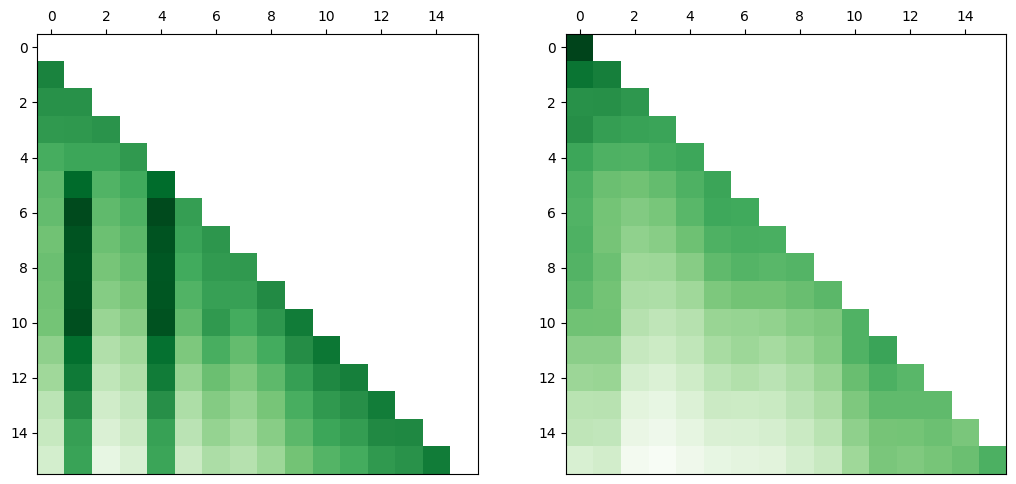

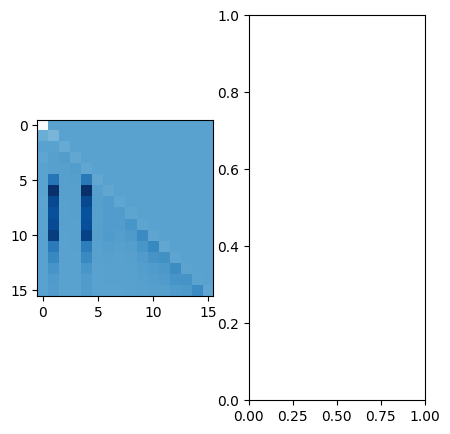

tensor([[  0.0000,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan],
        [  0.5895,   0.0000,      nan,      nan,      nan,      nan,      nan,
              nan,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan],
        [  1.0128,   0.9747,   0.0000,      nan,      nan,      nan,      nan,
              nan,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan],
        [  0.6732,   1.2290,   1.6913,   0.0000,      nan,      nan,      nan,
              nan,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan],
        [  0.7444,   1.6277,   1.6653,   2.0043,   0.0000,      nan,      nan,
              nan,      nan,      nan,      nan,      nan,      nan,      nan,
              nan,      nan],
        [  0.7007,  24.1986,   1.9765,   2.2119,  12.3929,  

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
fig, axes = plt.subplots(1, 2, figsize=(12.5, 15))
data = [moe_var, attn_var]
vars_cat = torch.cat(data)
var_min = vars_cat[vars_cat>0].min()
var_max = vars_cat.max()
comp = (moe_var - attn_var)
print(var_min, var_max)
for ind, raw_var in enumerate(data):
    c = ind % 2
    var = raw_var.detach().cpu().numpy()
    print(c)
    ax = axes[c]
    im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=var_min, vmax=var_max))
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
ax = axes[0]
im = ax.imshow(comp.detach().cpu().numpy(), cmap='Blues', aspect='equal')
plt.show()
print(moe_var/attn_var)